In [1]:
# ============================================
# GRADIENT BOOSTING - LOAN APPROVAL PREDICTION
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# ============================================
# CREATE LOAN DATASET
# ============================================

np.random.seed(42)

n = 1000

df = pd.DataFrame({
    "ApplicantIncome": np.random.randint(15000, 150000, n),
    "LoanAmount": np.random.randint(50000, 500000, n),
    "CreditScore": np.random.randint(300, 850, n),
    "EmploymentYears": np.random.randint(0, 30, n),
    "ExistingLoans": np.random.randint(0, 5, n)
})

# Generate approval probability
approval_probability = (
    0.20
    + 0.003 * (df["CreditScore"] - 300)
    + 0.000002 * df["ApplicantIncome"]
    - 0.0000015 * df["LoanAmount"]
    + 0.015 * df["EmploymentYears"]
    - 0.04 * df["ExistingLoans"]
)

approval_probability = np.clip(
    approval_probability,
    0.05,
    0.95
)

df["LoanApproved"] = (
    np.random.random(n) < approval_probability
).astype(int)

print("Dataset created successfully!")
print("Shape:", df.shape)

df.head()

Dataset created successfully!
Shape: (1000, 6)


,ApplicantIncome,LoanAmount,CreditScore,EmploymentYears,ExistingLoans,LoanApproved
0,136958,373412,455,7,1,1
1,146932,481459,590,19,1,1
2,118694,238456,443,12,0,0
3,134879,81653,405,16,0,1
4,125268,207729,719,16,1,1


In [3]:
# ============================================
# DATA EXPLORATION
# ============================================

print("Dataset Shape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nLoan Approval Distribution:")
print(df["LoanApproved"].value_counts())

display(df.describe())

Dataset Shape: (1000, 6)

Missing Values:
ApplicantIncome    0
LoanAmount         0
CreditScore        0
EmploymentYears    0
ExistingLoans      0
LoanApproved       0
dtype: int64

Loan Approval Distribution:
LoanApproved
1    729
0    271
Name: count, dtype: int64


,ApplicantIncome,LoanAmount,CreditScore,EmploymentYears,ExistingLoans,LoanApproved
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,84139.110000,278977.891000,583.455000,14.566000,1.988000,0.729000
std,40373.156018,128233.982276,156.803103,8.623805,1.418403,0.444699
min,15126.000000,51622.000000,300.000000,0.000000,0.000000,0.000000
25%,49605.000000,172275.500000,448.000000,7.000000,1.000000,0.000000
50%,84933.500000,278879.000000,581.000000,15.000000,2.000000,1.000000
75%,120346.500000,388574.000000,722.250000,22.000000,3.000000,1.000000
max,149869.000000,499662.000000,849.000000,29.000000,4.000000,1.000000


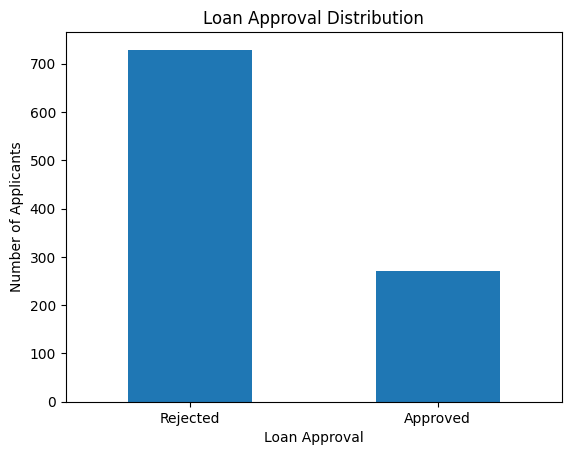

In [4]:
# ============================================
# LOAN APPROVAL DISTRIBUTION
# ============================================

df["LoanApproved"].value_counts().plot(
    kind="bar"
)

plt.xlabel("Loan Approval")
plt.ylabel("Number of Applicants")
plt.title("Loan Approval Distribution")
plt.xticks(
    [0, 1],
    ["Rejected", "Approved"],
    rotation=0
)

plt.show()

In [5]:
# ============================================
# 6. FEATURES AND TARGET
# ============================================

X = df.drop("LoanApproved", axis=1)
y = df["LoanApproved"]

print("Features:")
print(X.columns.tolist())

print("\nFeatures shape:", X.shape)
print("Target shape:", y.shape)

Features:
['ApplicantIncome', 'LoanAmount', 'CreditScore', 'EmploymentYears', 'ExistingLoans']

Features shape: (1000, 5)
Target shape: (1000,)


In [6]:
# ============================================
# 7. TRAIN / TEST SPLIT
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (800, 5)
Testing data: (200, 5)


In [7]:
# ============================================
# 8. TRAIN GRADIENT BOOSTING
# ============================================

gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb_model.fit(X_train, y_train)

print("Gradient Boosting model trained successfully!")

Gradient Boosting model trained successfully!


In [8]:
# ============================================
# 9. MAKE PREDICTIONS
# ============================================

y_pred = gb_model.predict(X_test)

print("Predictions generated successfully!")

print("\nFirst 20 predictions:")
print(y_pred[:20])

Predictions generated successfully!

First 20 predictions:
[0 1 1 1 1 1 0 0 0 0 1 1 1 1 1 1 0 1 1 1]


In [9]:
# ============================================
# 10. MODEL EVALUATION
# ============================================

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Gradient Boosting Performance")
print("=" * 40)
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

Gradient Boosting Performance
Accuracy  : 0.8500
Precision : 0.8919
Recall    : 0.9041
F1 Score  : 0.8980


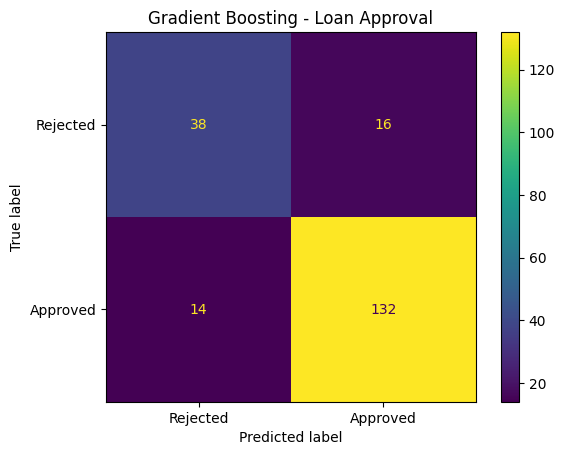

In [10]:
# ============================================
# 11. CONFUSION MATRIX
# ============================================

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Rejected", "Approved"]
)

disp.plot()

plt.title("Gradient Boosting - Loan Approval")
plt.show()

Feature Importance:
CreditScore        0.596310
LoanAmount         0.188409
EmploymentYears    0.108598
ApplicantIncome    0.080443
ExistingLoans      0.026240
dtype: float64


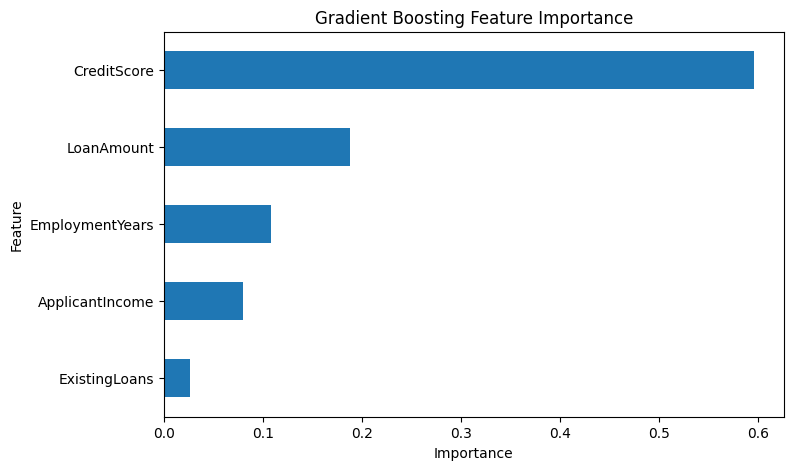

In [11]:
# ============================================
# 12. FEATURE IMPORTANCE
# ============================================

importance = pd.Series(
    gb_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("Feature Importance:")
print(importance)

plt.figure(figsize=(8, 5))

importance.sort_values().plot(kind="barh")

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Gradient Boosting Feature Importance")

plt.show()

In [12]:
# ============================================
# 13. NEW LOAN APPLICATION
# ============================================

new_applicant = pd.DataFrame({
    "ApplicantIncome": [80000],
    "LoanAmount": [200000],
    "CreditScore": [750],
    "EmploymentYears": [8],
    "ExistingLoans": [1]
})

prediction = gb_model.predict(new_applicant)[0]
probability = gb_model.predict_proba(new_applicant)[0]

if prediction == 1:
    result = "Loan likely to be approved"
else:
    result = "Loan likely to be rejected"

print("Prediction:", result)
print(f"Probability of rejection: {probability[0]:.2%}")
print(f"Probability of approval: {probability[1]:.2%}")

Prediction: Loan likely to be approved
Probability of rejection: 9.48%
Probability of approval: 90.52%
